In [1]:
import kagglehub

In [2]:
path = kagglehub.dataset_download("prajitdatta/movielens-100k-dataset")

print("Path: ", path)

Path:  C:\Users\Admin\.cache\kagglehub\datasets\prajitdatta\movielens-100k-dataset\versions\1


## Import necessary libraries

In [8]:
# Data handling
import pandas as pd
import numpy as np

import os

# data visualization


In [4]:
os.listdir(path)

['ml-100k']

In [9]:
path = os.path.join(path, "ml-100k")

In [4]:
os.listdir(path)

['ml-100k']

In [10]:
# read README
readme_file = "README"

with open(os.path.join(path, readme_file)) as f:
    readme = f.read()

    print(readme)

SUMMARY & USAGE LICENSE

MovieLens data sets were collected by the GroupLens Research Project
at the University of Minnesota.
 
This data set consists of:
	* 100,000 ratings (1-5) from 943 users on 1682 movies. 
	* Each user has rated at least 20 movies. 
        * Simple demographic info for the users (age, gender, occupation, zip)

The data was collected through the MovieLens web site
(movielens.umn.edu) during the seven-month period from September 19th, 
1997 through April 22nd, 1998. This data has been cleaned up - users
who had less than 20 ratings or did not have complete demographic
information were removed from this data set. Detailed descriptions of
the data file can be found at the end of this file.

Neither the University of Minnesota nor any of the researchers
involved can guarantee the correctness of the data, its suitability
for any particular purpose, or the validity of results based on the
use of the data set.  The data set may be used for any research
purposes under th

In [11]:
# declare data path
file_names = ['u.data','u.genre', 'u.info', 'u.item','u.occupation','u.user',]


data_path = os.path.join(path, "u.data")
genre_path = os.path.join(path, "u.genre")

info_path = os.path.join(path, "u.info")

item_path = os.path.join(path, "u.item")

occ_path = os.path.join(path, "u.occupation")

user_path = os.path.join(path, "u.user")


In [12]:
from pprint import pprint


def read_raw(file_path, limit_lines= -1):
    with open(file_path, "r+t") as f:
        if limit_lines < 0:
            content = f.read()
        else:
            counter = 0
            content = ""
            while counter < limit_lines:
                line = f.readline()
                if not line:
                    break
                content += line
                counter += 1


        pprint(content)


In [64]:
read_raw(item_path, limit_lines = 50)

('1|Toy Story '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0\n'
 '2|GoldenEye '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0\n'
 '3|Four Rooms '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Four%20Rooms%20(1995)|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0\n'
 '4|Get Shorty '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Get%20Shorty%20(1995)|0|1|0|0|0|1|0|0|1|0|0|0|0|0|0|0|0|0|0\n'
 '5|Copycat '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Copycat%20(1995)|0|0|0|0|0|0|1|0|1|0|0|0|0|0|0|0|1|0|0\n'
 '6|Shanghai Triad (Yao a yao yao dao waipo qiao) '
 '(1995)|01-Jan-1995||http://us.imdb.com/Title?Yao+a+yao+yao+dao+waipo+qiao+(1995)|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|0|0|0|0\n'
 '7|Twelve Monkeys '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Twelve%20Monkeys%20(1995)|0|0|0|0|0|0|0|0|1|0|0|0|0|0|0|1|0|0|0\n'
 '8|Babe '
 '(1995)|

In [86]:
read_raw(data_path, limit_lines=10)

('196\t242\t3\t881250949\n'
 '186\t302\t3\t891717742\n'
 '22\t377\t1\t878887116\n'
 '244\t51\t2\t880606923\n'
 '166\t346\t1\t886397596\n'
 '298\t474\t4\t884182806\n'
 '115\t265\t2\t881171488\n'
 '253\t465\t5\t891628467\n'
 '305\t451\t3\t886324817\n'
 '6\t86\t3\t883603013\n')


In [34]:
read_raw(genre_path)

('unknown|0\n'
 'Action|1\n'
 'Adventure|2\n'
 'Animation|3\n'
 "Children's|4\n"
 'Comedy|5\n'
 'Crime|6\n'
 'Documentary|7\n'
 'Drama|8\n'
 'Fantasy|9\n'
 'Film-Noir|10\n'
 'Horror|11\n'
 'Musical|12\n'
 'Mystery|13\n'
 'Romance|14\n'
 'Sci-Fi|15\n'
 'Thriller|16\n'
 'War|17\n'
 'Western|18\n'
 '\n')


In [33]:
read_raw(info_path)

'943 users\n1682 items\n100000 ratings\n'


In [122]:
read_raw(item_path, 2)

('1|Toy Story '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?Toy%20Story%20(1995)|0|0|0|1|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0\n'
 '2|GoldenEye '
 '(1995)|01-Jan-1995||http://us.imdb.com/M/title-exact?GoldenEye%20(1995)|0|1|1|0|0|0|0|0|0|0|0|0|0|0|0|0|1|0|0\n')


In [37]:
read_raw(occ_path)

('administrator\n'
 'artist\n'
 'doctor\n'
 'educator\n'
 'engineer\n'
 'entertainment\n'
 'executive\n'
 'healthcare\n'
 'homemaker\n'
 'lawyer\n'
 'librarian\n'
 'marketing\n'
 'none\n'
 'other\n'
 'programmer\n'
 'retired\n'
 'salesman\n'
 'scientist\n'
 'student\n'
 'technician\n'
 'writer\n')


In [39]:
read_raw(user_path, 5)

('1|24|M|technician|85711\n'
 '2|53|F|other|94043\n'
 '3|23|M|writer|32067\n'
 '4|24|M|technician|43537\n'
 '5|33|F|other|15213\n')


## Reading Data

In [13]:
rating_df = pd.read_csv(data_path, sep = "\t",
                        names = ["user_id", "item_id", "rating", "timestamp"])

rating_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   item_id    100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [50]:
rating_df.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [51]:
rating_df.isna().value_counts()

user_id  item_id  rating  timestamp
False    False    False   False        100000
Name: count, dtype: int64

In [52]:
rating_df.describe()

,user_id,item_id,rating,timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [14]:
rating_df["rating"] = rating_df["rating"].astype(float)
rating_df.iloc[1:5]["rating"]

1    3.0
2    1.0
3    2.0
4    1.0
Name: rating, dtype: float64

In [15]:
print("mean: ", rating_df["rating"].mean())
print("median: ", rating_df["rating"].median())
print("mode: ", rating_df["rating"].mode())

mean:  3.52986
median:  4.0
mode:  0    4.0
Name: rating, dtype: float64


In [18]:
genre_df = pd.read_csv(genre_path, sep="|", names= ["genre_type", "order"])

genre_df

,genre_type,order
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4
5,Comedy,5
6,Crime,6
7,Documentary,7
8,Drama,8
9,Fantasy,9


In [19]:
item_genres = genre_df.sort_values(by = "order")["genre_type"].astype(str).tolist()
item_genres

['unknown',
 'Action',
 'Adventure',
 'Animation',
 "Children's",
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']

In [20]:
item_col_names = ["item_id", "title", "released_date", "imdb_url", *item_genres]
mapping_dtypes = {k: int for k in item_col_names}

mapping_dtypes["title"] = str
mapping_dtypes["released_date"] = str
mapping_dtypes["imdb_url"] = str

pprint(item_col_names)

['item_id',
 'title',
 'released_date',
 'imdb_url',
 'unknown',
 'Action',
 'Adventure',
 'Animation',
 "Children's",
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western']


In [21]:
def read_item_info() -> dict:
    data = {k: [] for k in item_col_names}

    with open(item_path, "r+t") as f:
        while True:
            line = f.readline()
            if not line:
                break
            #print(line)
            items = line.split("|")
            items.remove("")
            #print(items)
            for idx, k in enumerate(item_col_names):
                data[k].append(mapping_dtypes[k](items[idx]))
    return data


In [22]:
item_data = read_item_info()

print(item_data)

{'item_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

In [23]:
for col in item_col_names:
    print("col:", col, " has: ", len(item_data[col]), "values")

col: item_id  has:  1682 values
col: title  has:  1682 values
col: released_date  has:  1682 values
col: imdb_url  has:  1682 values
col: unknown  has:  1682 values
col: Action  has:  1682 values
col: Adventure  has:  1682 values
col: Animation  has:  1682 values
col: Children's  has:  1682 values
col: Comedy  has:  1682 values
col: Crime  has:  1682 values
col: Documentary  has:  1682 values
col: Drama  has:  1682 values
col: Fantasy  has:  1682 values
col: Film-Noir  has:  1682 values
col: Horror  has:  1682 values
col: Musical  has:  1682 values
col: Mystery  has:  1682 values
col: Romance  has:  1682 values
col: Sci-Fi  has:  1682 values
col: Thriller  has:  1682 values
col: War  has:  1682 values
col: Western  has:  1682 values


In [24]:
item_data_df = pd.DataFrame(data = item_data)

In [25]:
# convert data
item_data_df["title"] = item_data_df["title"].astype(str)
item_data_df["imdb_url"] = item_data_df["imdb_url"].astype(str)
item_data_df["released_date"] = pd.to_datetime(item_data_df["released_date"], format= "%d-%b-%Y")

item_data_df.dtypes

item_id                   int64
title                    object
released_date    datetime64[ns]
imdb_url                 object
unknown                   int64
Action                    int64
Adventure                 int64
Animation                 int64
Children's                int64
Comedy                    int64
Crime                     int64
Documentary               int64
Drama                     int64
Fantasy                   int64
Film-Noir                 int64
Horror                    int64
Musical                   int64
Mystery                   int64
Romance                   int64
Sci-Fi                    int64
Thriller                  int64
War                       int64
Western                   int64
dtype: object

In [27]:
user_columns = ['user_id', 'age', 'gender', 'occupation', 'zip_code']

In [28]:
user_data_df = pd.read_csv(user_path, sep = "|", names = user_columns)

user_data_df.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


## Data Visualization

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

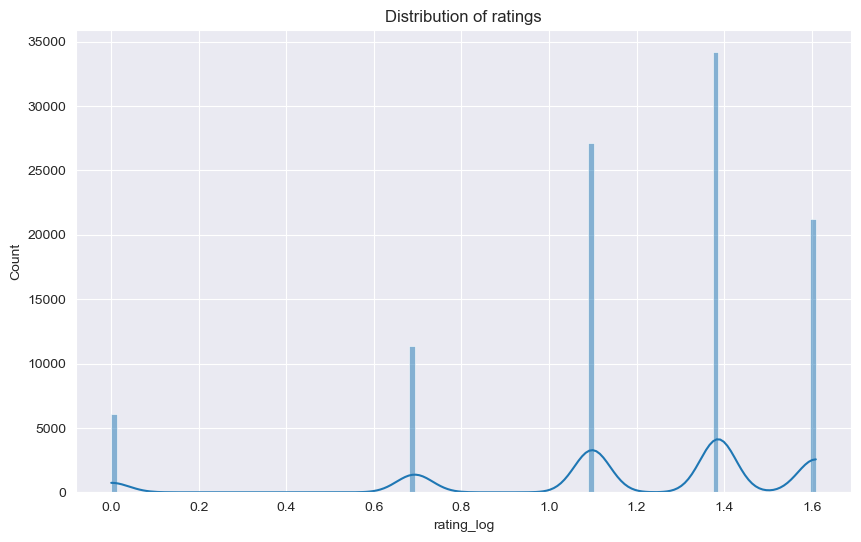

In [17]:
plt.figure(figsize=(10, 6))

rating_df["rating_log"] = np.log(rating_df["rating"])
sns.histplot(rating_df, x ="rating_log", kde = True)

plt.title("Distribution of ratings")


plt.show()



